In [1]:
import pandas as pd

features = pd.read_csv(r"Wallmart_sales_prediction\features.csv")
stores = pd.read_csv(r"Wallmart_sales_prediction\stores.csv")
test = pd.read_csv(r"Wallmart_sales_prediction\test.csv")
train = pd.read_csv(r"Wallmart_sales_prediction\train.csv")

### Fixing the internals of Train Dataset

fixing "feature_dateset_errors"

In [2]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [3]:
features["Date"] = pd.to_datetime(features["Date"])
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB


In [4]:
features.isna().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

markdown1, 2,3,4 and 5 -> This means Amount of promotional price reductions for first, second, third, fourth and fifth type of Walmart promo campaign that week.

CPI : Consumer Price Index in the store’s region, indicating the general price level/inflation.

Unemployment : Unemployment rate in the store’s region for that week.

In [5]:
all_markdowns = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in all_markdowns:
    features[col] = features[col].fillna(0.0)

features["CPI"] = features.groupby("Store")["CPI"].transform(lambda s: s.fillna(s.median()))

features["Unemployment"] = features.groupby("Store")["Unemployment"].transform(lambda s: s.fillna(s.median()))

features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     8190 non-null   float64       
 5   MarkDown2     8190 non-null   float64       
 6   MarkDown3     8190 non-null   float64       
 7   MarkDown4     8190 non-null   float64       
 8   MarkDown5     8190 non-null   float64       
 9   CPI           8190 non-null   float64       
 10  Unemployment  8190 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB


fixing "Train_dateset_errors"

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [7]:
train["Date"] = pd.to_datetime(train["Date"])
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


fixing the "Store Dataset"

In [8]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


merging "stores" and "features" with "train" dataset

In [9]:
train_full = (train.merge(stores, on = "Store", how = "left")).merge(features, on = ["Store", "Date"], how = "left")

In [10]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     421570 non-null  float64       
 10  MarkDown2     421570 non-null  float64       
 11  MarkDown3     421570 non-null  float64       
 12  MarkDown4     421570 non-null  float64       
 13  MarkDown5     421570 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

In [11]:
(train_full["IsHoliday_y"]  == train_full["IsHoliday_x"]).sum() #if this equals the number of rows itself then that means both the column's values are same and hence its better to drop one

421570

In [12]:
train_full["IsHoliday"] = train_full["IsHoliday_x"]
train_full.drop(columns = ["IsHoliday_y", "IsHoliday_x"], inplace = True)

train_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   Type          421570 non-null  object        
 5   Size          421570 non-null  int64         
 6   Temperature   421570 non-null  float64       
 7   Fuel_Price    421570 non-null  float64       
 8   MarkDown1     421570 non-null  float64       
 9   MarkDown2     421570 non-null  float64       
 10  MarkDown3     421570 non-null  float64       
 11  MarkDown4     421570 non-null  float64       
 12  MarkDown5     421570 non-null  float64       
 13  CPI           421570 non-null  float64       
 14  Unemployment  421570 non-null  float64       
 15  IsHoliday     421

### Fixing the Internals of Test Dataset

In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB


In [14]:
test["Date"] = pd.to_datetime(test["Date"])

test_full = test.merge(stores, on = "Store", how = "left").merge(features, on = ["Store", "Date"], how = "left")

test_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 115064 entries, 0 to 115063
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   IsHoliday_x   115064 non-null  bool          
 4   Type          115064 non-null  object        
 5   Size          115064 non-null  int64         
 6   Temperature   115064 non-null  float64       
 7   Fuel_Price    115064 non-null  float64       
 8   MarkDown1     115064 non-null  float64       
 9   MarkDown2     115064 non-null  float64       
 10  MarkDown3     115064 non-null  float64       
 11  MarkDown4     115064 non-null  float64       
 12  MarkDown5     115064 non-null  float64       
 13  CPI           115064 non-null  float64       
 14  Unemployment  115064 non-null  float64       
 15  IsHoliday_y   115

In [15]:
test_full.isna().sum()

Store           0
Dept            0
Date            0
IsHoliday_x     0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday_y     0
dtype: int64

In [16]:
#since both IsHoliday_x and IsHoliday_y are same it is better if we Drop it with a new column "IsHoliday" equal to any one of them

test_full["IsHoliday"] = test_full["IsHoliday_x"]
test_full.drop(columns = ["IsHoliday_x", "IsHoliday_y"], inplace = True)
test_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 115064 entries, 0 to 115063
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   Type          115064 non-null  object        
 4   Size          115064 non-null  int64         
 5   Temperature   115064 non-null  float64       
 6   Fuel_Price    115064 non-null  float64       
 7   MarkDown1     115064 non-null  float64       
 8   MarkDown2     115064 non-null  float64       
 9   MarkDown3     115064 non-null  float64       
 10  MarkDown4     115064 non-null  float64       
 11  MarkDown5     115064 non-null  float64       
 12  CPI           115064 non-null  float64       
 13  Unemployment  115064 non-null  float64       
 14  IsHoliday     115064 non-null  bool          
dtypes: bool(1), datet

In [17]:
test_full.info() #15 columns

<class 'pandas.core.frame.DataFrame'>
Int64Index: 115064 entries, 0 to 115063
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   Type          115064 non-null  object        
 4   Size          115064 non-null  int64         
 5   Temperature   115064 non-null  float64       
 6   Fuel_Price    115064 non-null  float64       
 7   MarkDown1     115064 non-null  float64       
 8   MarkDown2     115064 non-null  float64       
 9   MarkDown3     115064 non-null  float64       
 10  MarkDown4     115064 non-null  float64       
 11  MarkDown5     115064 non-null  float64       
 12  CPI           115064 non-null  float64       
 13  Unemployment  115064 non-null  float64       
 14  IsHoliday     115064 non-null  bool          
dtypes: bool(1), datet

In [18]:
train_full.info() #16 columns

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   Type          421570 non-null  object        
 5   Size          421570 non-null  int64         
 6   Temperature   421570 non-null  float64       
 7   Fuel_Price    421570 non-null  float64       
 8   MarkDown1     421570 non-null  float64       
 9   MarkDown2     421570 non-null  float64       
 10  MarkDown3     421570 non-null  float64       
 11  MarkDown4     421570 non-null  float64       
 12  MarkDown5     421570 non-null  float64       
 13  CPI           421570 non-null  float64       
 14  Unemployment  421570 non-null  float64       
 15  IsHoliday     421

In [19]:
train_full["Type"].value_counts()

A    215478
B    163495
C     42597
Name: Type, dtype: int64

In [20]:
from sklearn.preprocessing import OrdinalEncoder
oen = OrdinalEncoder()

cat_cols = ["Type", "IsHoliday"]

train_full[cat_cols] = oen.fit_transform(train_full[cat_cols])

train_full.head()

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,1,2010-02-05,24924.50,0.0,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0.0
1,1,1,2010-02-12,46039.49,0.0,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,1.0
2,1,1,2010-02-19,41595.55,0.0,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0.0
3,1,1,2010-02-26,19403.54,0.0,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0.0
4,1,1,2010-03-05,21827.90,0.0,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0.0


### EDA

In [21]:
train_full.describe()

,Store,Dept,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,0.589912,136727.915739,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,0.070358
std,12.785297,30.492054,22711.183519,0.666337,60980.583328,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,0.255750
min,1.000000,1.000000,-4988.940000,0.000000,34875.000000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,0.000000
25%,11.000000,18.000000,2079.650000,0.000000,93638.000000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,0.000000
50%,22.000000,37.000000,7612.030000,0.000000,140167.000000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,0.000000
75%,33.000000,74.000000,20205.852500,1.000000,202505.000000,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,0.000000
max,45.000000,99.000000,693099.360000,2.000000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,1.000000


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

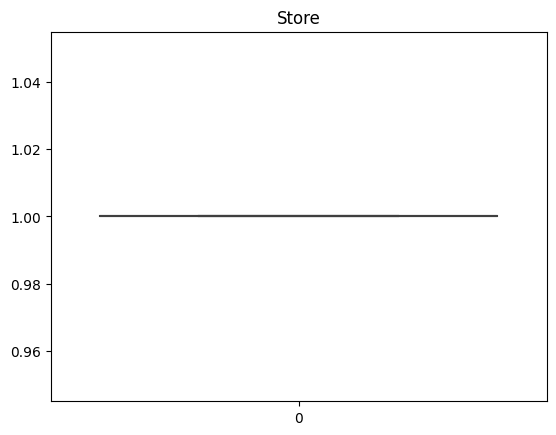

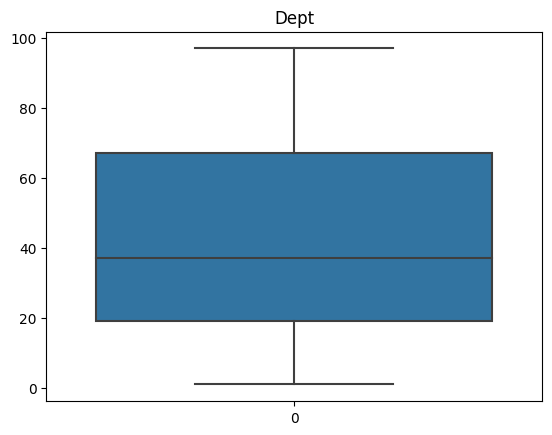

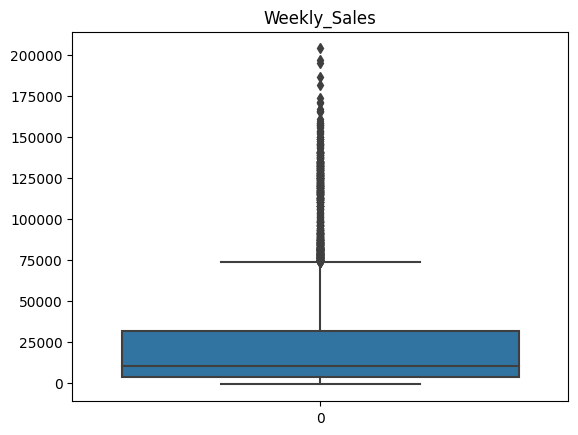

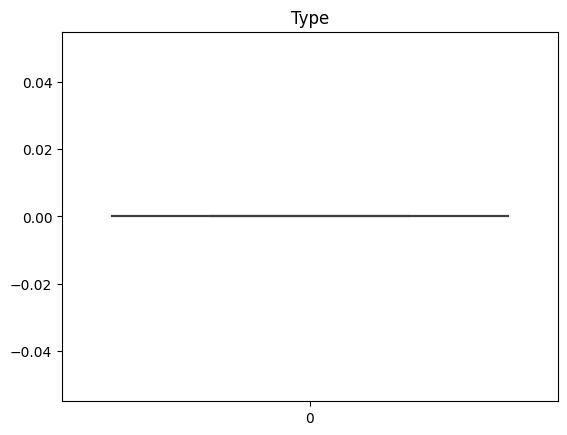

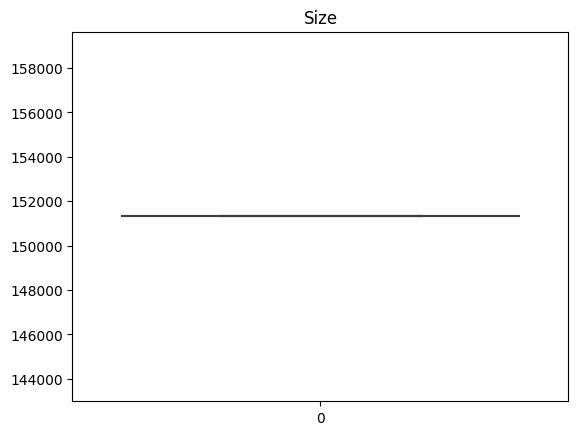

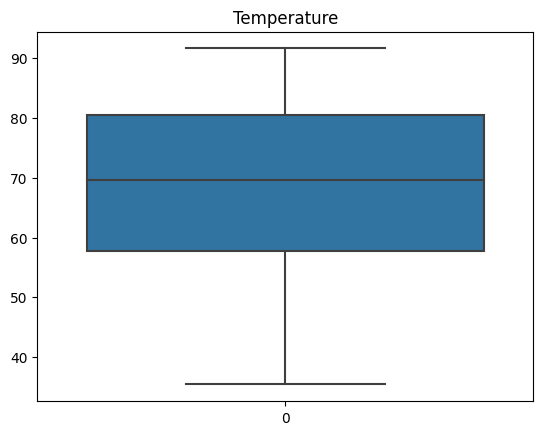

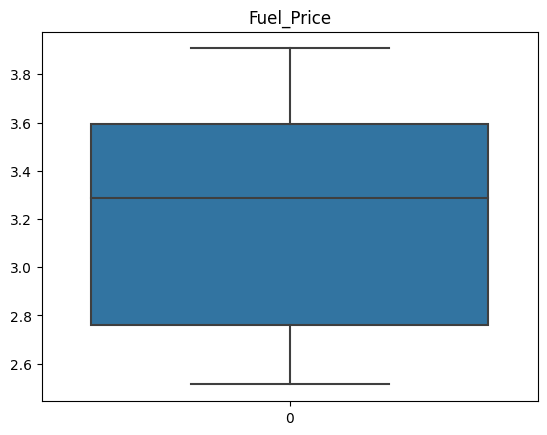

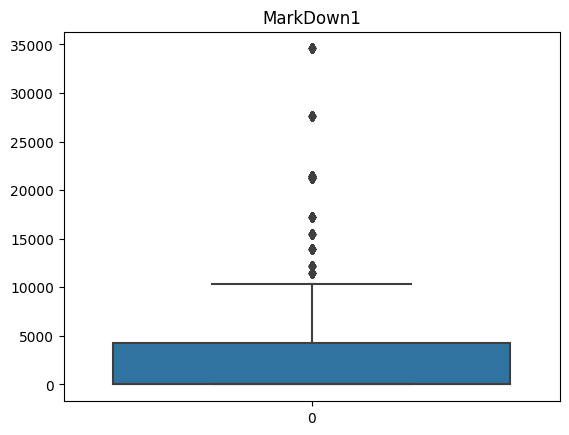

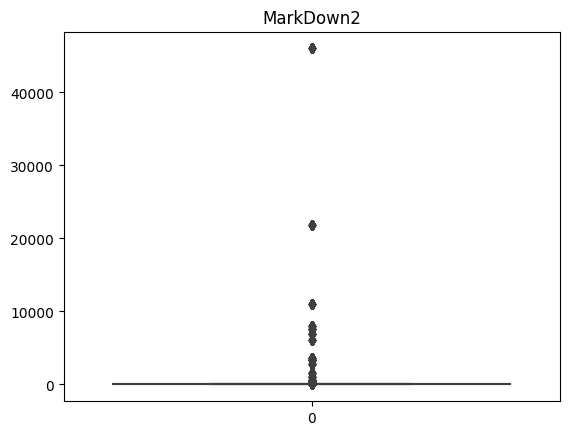

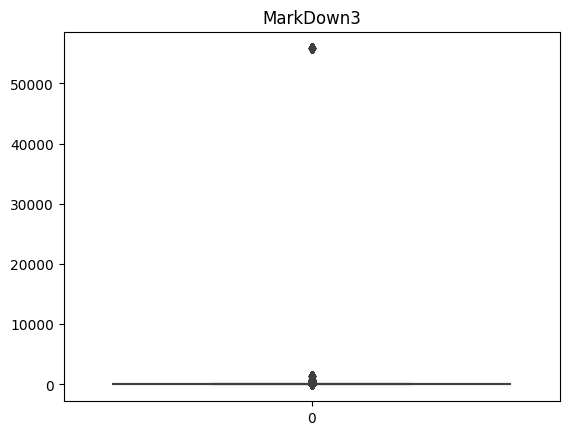

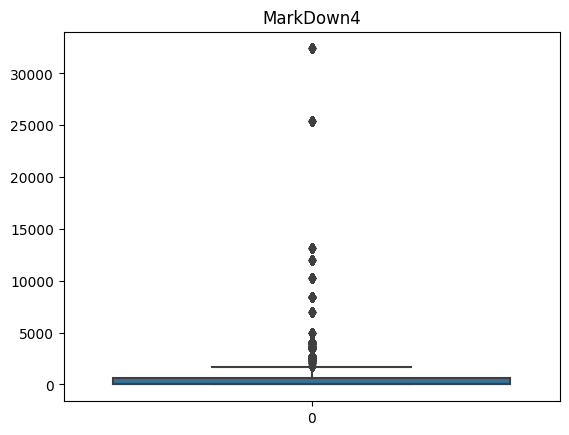

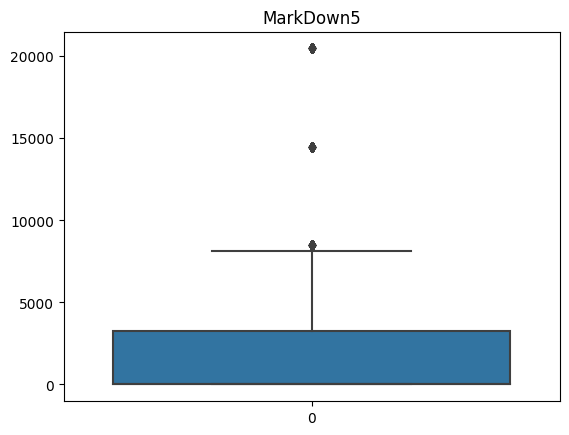

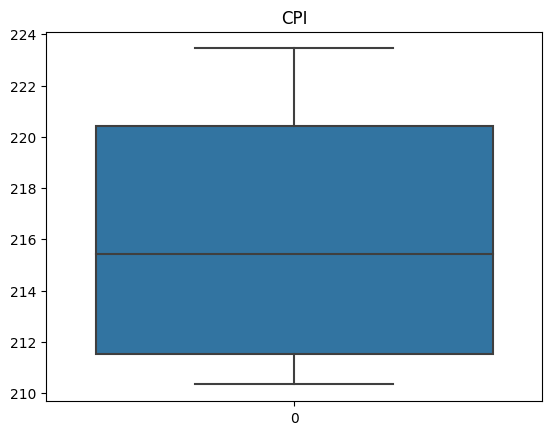

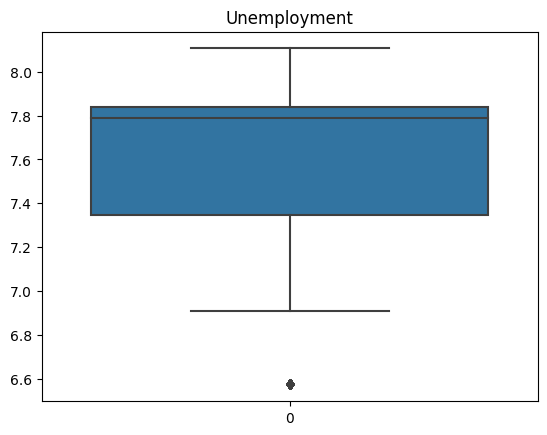

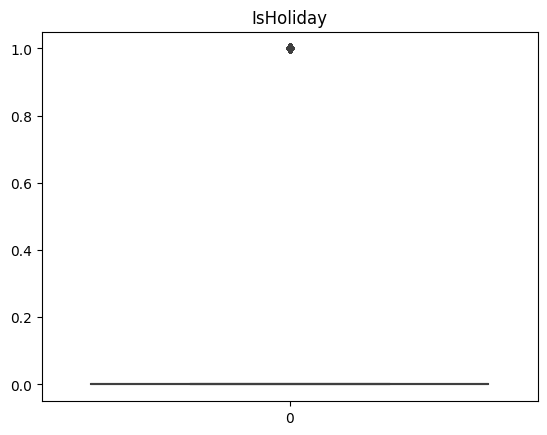

In [23]:
temp = train_full[:10000]
for col in temp.columns:
    if col == "Date":
        continue
    sns.boxplot(temp[col])
    plt.title(col)
    plt.show()

fixing the outliers in Unemployment and Weekly_Sales

In [24]:
import numpy as np
outlier_col = ["Unemployment", "Weekly_Sales"]

for col in outlier_col:
    train_full[col] = np.sign(train_full["Weekly_Sales"])*np.log1p(np.abs(train_full[col]))

<AxesSubplot:>

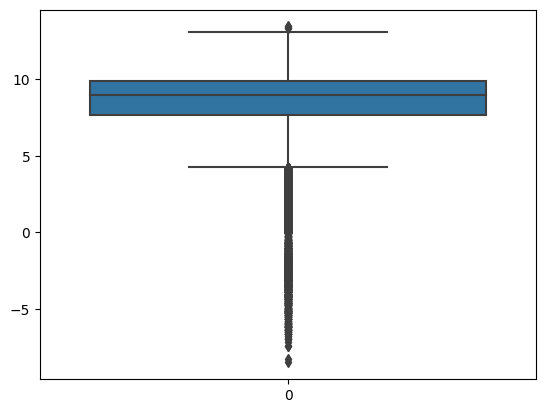

In [25]:
sns.boxplot(train_full["Weekly_Sales"])

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

<Figure size 400x300 with 0 Axes>

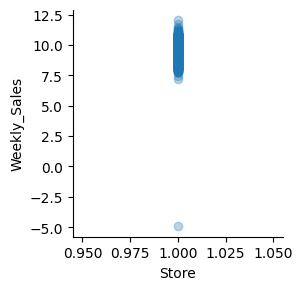

<Figure size 400x300 with 0 Axes>

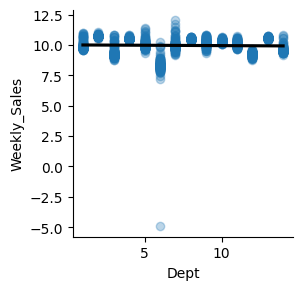

<Figure size 400x300 with 0 Axes>

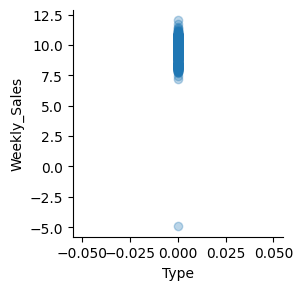

<Figure size 400x300 with 0 Axes>

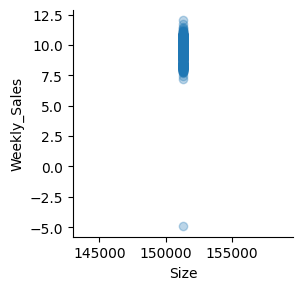

<Figure size 400x300 with 0 Axes>

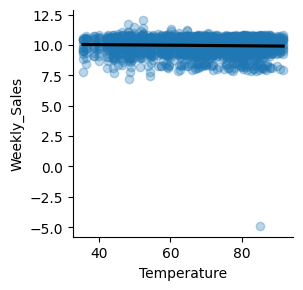

<Figure size 400x300 with 0 Axes>

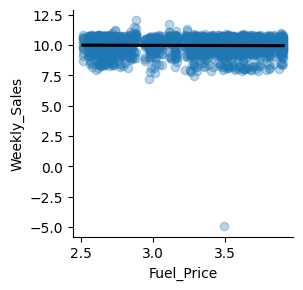

<Figure size 400x300 with 0 Axes>

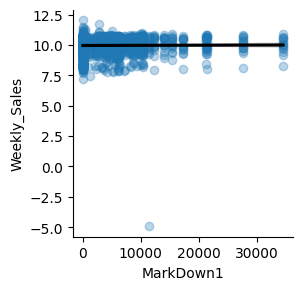

<Figure size 400x300 with 0 Axes>

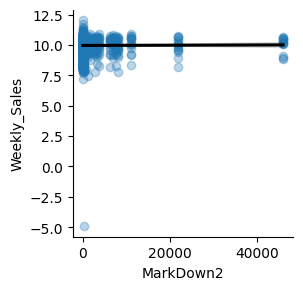

<Figure size 400x300 with 0 Axes>

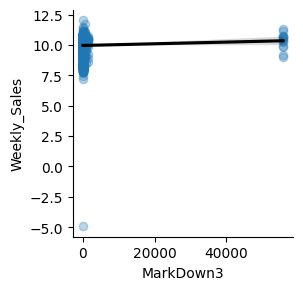

<Figure size 400x300 with 0 Axes>

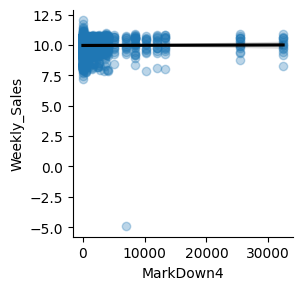

<Figure size 400x300 with 0 Axes>

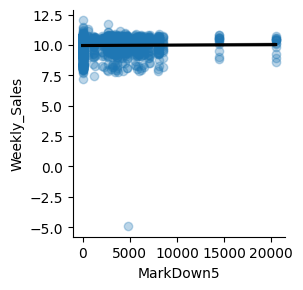

<Figure size 400x300 with 0 Axes>

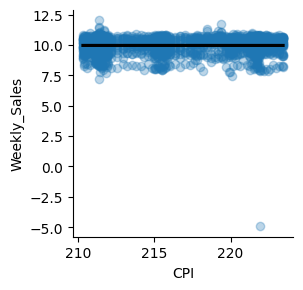

<Figure size 400x300 with 0 Axes>

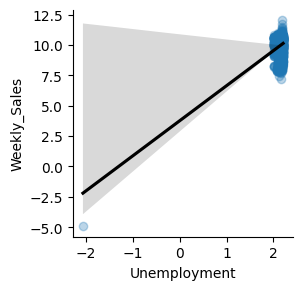

<Figure size 400x300 with 0 Axes>

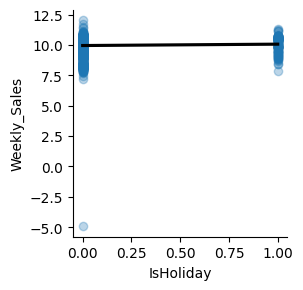

In [27]:
temp = train_full[:2000]   #SLICING THE Dataset for simplicity

for col in temp.columns:
    if col == "Weekly_Sales" or col == "Date":
        continue
    plt.figure(figsize = (4,3))
    sns.lmplot(data = temp, x = col, y = "Weekly_Sales", height = 3, palette = 'black', scatter_kws = {"alpha" : 0.3}, line_kws = {'color' : 'black'})
    plt.xlabel(col)
    plt.ylabel("Weekly_Sales")
    plt.tight_layout
    plt.show()

In [28]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   Type          421570 non-null  float64       
 5   Size          421570 non-null  int64         
 6   Temperature   421570 non-null  float64       
 7   Fuel_Price    421570 non-null  float64       
 8   MarkDown1     421570 non-null  float64       
 9   MarkDown2     421570 non-null  float64       
 10  MarkDown3     421570 non-null  float64       
 11  MarkDown4     421570 non-null  float64       
 12  MarkDown5     421570 non-null  float64       
 13  CPI           421570 non-null  float64       
 14  Unemployment  421570 non-null  float64       
 15  IsHoliday     421

In [29]:
train_full.head()

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,1,2010-02-05,10.123647,0.0,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,2.208934,0.0
1,1,1,2010-02-12,10.737277,0.0,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,2.208934,1.0
2,1,1,2010-02-19,10.635773,0.0,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,2.208934,0.0
3,1,1,2010-02-26,9.873262,0.0,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,2.208934,0.0
4,1,1,2010-03-05,9.990990,0.0,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,2.208934,0.0


In [30]:
train_full["Year"] = train_full["Date"].dt.year
train_full["Month"] = train_full["Date"].dt.month

train_full.drop(columns = ["Date"], inplace = True)

In [31]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Weekly_Sales  421570 non-null  float64
 3   Type          421570 non-null  float64
 4   Size          421570 non-null  int64  
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     421570 non-null  float64
 8   MarkDown2     421570 non-null  float64
 9   MarkDown3     421570 non-null  float64
 10  MarkDown4     421570 non-null  float64
 11  MarkDown5     421570 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  IsHoliday     421570 non-null  float64
 15  Year          421570 non-null  int64  
 16  Month         421570 non-null  int64  
dtypes: float64(12), int64(5)
memory usage: 74.0 MB


In [32]:
train_full.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'Type', 'Size', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month'],
      dtype='object')

In [33]:
from xgboost import XGBRegressor

all_features = ['Store', 'Dept', 'Type', 'Size', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month',]

preprocess = ColumnTransformer(transformers = [('pass', 'passthrough', all_features)])


xgbr = XGBRegressor(objective = "reg:squarederror", n_estimators = 200, learning_rate = 0.5, max_depth = 6, subsample = 0.8, colsample_bytree = 0.8, random_state = 42, n_jobs = -1)

model = Pipeline(steps = [("pre", preprocess), ("model", xgbr)])

In [34]:
from sklearn.model_selection import train_test_split

X = train_full.drop(columns = ["Weekly_Sales"])
y = train_full["Weekly_Sales"]

In [35]:
[X_train, X_test, y_train, y_test] = train_test_split(X,y, random_state = 42, test_size = 0.2)

In [36]:
model.fit(X_train,y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('pass', 'passthrough',
                                                  ['Store', 'Dept', 'Type',
                                                   'Size', 'Temperature',
                                                   'Fuel_Price', 'MarkDown1',
                                                   'MarkDown2', 'MarkDown3',
                                                   'MarkDown4', 'MarkDown5',
                                                   'CPI', 'Unemployment',
                                                   'IsHoliday', 'Year',
                                                   'Month'])])),
                ('model',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_byno...
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interact

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)
r2= r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"mean absolute error : {mae}\nmean squared error : {mse}\nr2 score : {r2}\nroot mean squared error : {rmse}")

mean absolute error : 0.27199466647785725
mean squared error : 0.20945594997845288
r2 score : 0.9532607312966641
root mean squared error : 0.45766357729062607


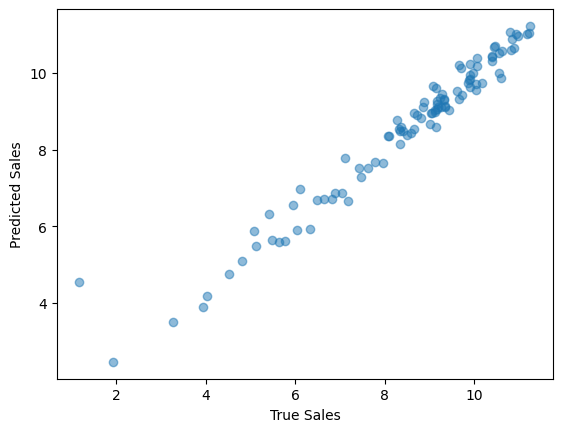

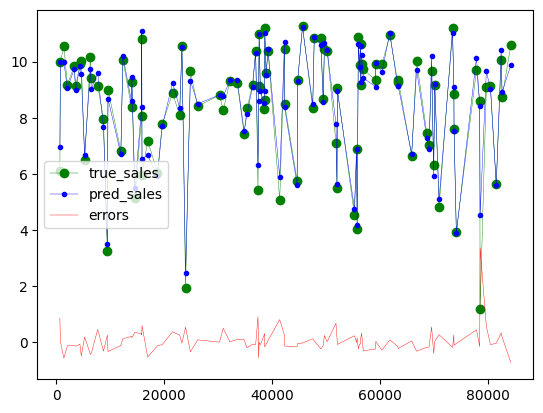

In [39]:
idx = np.random.choice(len(y_test), size = 100, replace = False)

idx = np.sort(idx)

y_t = y_test.iloc[idx]
y_p = y_pred[idx]
errors = y_p - y_t

plt.scatter(y_t, y_p, alpha = 0.5)
plt.xlabel("True Sales")
plt.ylabel("Predicted Sales")
plt.show()

plt.plot(idx,y_t, color = 'green', marker = 'o', linewidth = 0.3, label = "true_sales")
plt.plot(idx,y_p, color = 'blue', marker = '.', linewidth = 0.3, label = "pred_sales")
plt.plot(idx, errors, color = 'red', linewidth = '0.3', label = "errors")
plt.legend(loc = 'best')



In [40]:
import joblib

joblib.dump(model, "Wallmart_sales_predictor.pkl")

['Wallmart_sales_predictor.pkl']